In [1]:
# %%
# =============================================================================
# CoCoAH vs BWDB Validation Notebook
# =============================================================================
# Compares CoCoAH-detected haor polygons against the official BWDB Waterbodies
# shapefile to assess detection accuracy.
#
# Install if needed:
#   pip install geopandas shapely pandas numpy matplotlib seaborn rtree --break-system-packages
# =============================================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box
from shapely.ops import unary_union
import warnings
warnings.filterwarnings("ignore")

# %%
# =============================================================================
# CONFIGURATION
# =============================================================================

DATA_DIR = "/work/a06/wasif/haor_flood_analysis"

# CoCoAH boundaries (exported from GEE)
COCOAH_SHP = os.path.join(DATA_DIR, "cocoah_haor_boundaries.shp")

# BWDB Waterbodies shapefile
BWDB_SHP = os.path.join(DATA_DIR, "Waterbodies", "Waterbodiesdeg.shp")

# Haor AOI for filtering
HAOR_BBOX = [89.8, 23.5, 92.8, 25.5]

# Output directory for figures and tables
OUT_DIR = os.path.join(DATA_DIR, "validation")
os.makedirs(OUT_DIR, exist_ok=True)

# Overlap threshold for "matched" (IoU = Intersection over Union)
IOU_MATCH_THRESHOLD = 0.30   # 30% IoU = considered a match
OVERLAP_THRESHOLD = 0.50     # 50% area overlap = considered substantial overlap

print(f"CoCoAH file: {COCOAH_SHP}")
print(f"BWDB file:   {BWDB_SHP}")
print(f"Output dir:  {OUT_DIR}")


CoCoAH file: /work/a06/wasif/haor_flood_analysis/cocoah_haor_boundaries.shp
BWDB file:   /work/a06/wasif/haor_flood_analysis/Waterbodies/Waterbodiesdeg.shp
Output dir:  /work/a06/wasif/haor_flood_analysis/validation


In [2]:
# %%
# =============================================================================
# CELL 1: LOAD BOTH SHAPEFILES
# =============================================================================

print("\n=== Loading shapefiles ===")

# Load CoCoAH
cocoah = gpd.read_file(COCOAH_SHP)
print(f"\nCoCoAH:")
print(f"  Features: {len(cocoah)}")
print(f"  CRS: {cocoah.crs}")
print(f"  Columns: {list(cocoah.columns)}")

# Load BWDB and filter to haor AOI
bwdb_all = gpd.read_file(BWDB_SHP)
print(f"\nBWDB (full Bangladesh):")
print(f"  Features: {len(bwdb_all)}")
print(f"  CRS: {bwdb_all.crs}")

# Filter BWDB to haor AOI
haor_bbox_geom = box(*HAOR_BBOX)
bwdb = bwdb_all[bwdb_all.intersects(haor_bbox_geom)].copy().reset_index(drop=True)
print(f"\nBWDB (in haor AOI):")
print(f"  Features: {len(bwdb)}")
print(f"  Columns: {list(bwdb.columns)}")

# Ensure both are in the same CRS (geographic for now, then reproject for area)
if cocoah.crs != bwdb.crs:
    cocoah = cocoah.to_crs(bwdb.crs)



=== Loading shapefiles ===

CoCoAH:
  Features: 1345
  CRS: EPSG:4326
  Columns: ['compactnes', 'count', 'label', 'geometry']

BWDB (full Bangladesh):
  Features: 13096
  CRS: EPSG:4326

BWDB (in haor AOI):
  Features: 6686
  Columns: ['AREA', 'PERIMETER', 'WBSBD97_', 'WBSBD97_ID', 'WBSBD_', 'WBSBD_ID', 'WBCODE', 'WBNAME', 'TYPE', 'CATCH_SWMC', 'CONNECTIVI', 'AREA_HA', 'AREA_SQKM', 'geometry']


In [3]:
# %%
# =============================================================================
# CELL 2: REPROJECT TO METRIC CRS FOR ACCURATE AREA CALCULATION
# =============================================================================
# UTM Zone 46N covers most of NE Bangladesh — EPSG:32646
# This gives accurate area in m² (not square degrees)

print("\n=== Reprojecting to UTM 46N for accurate areas ===")

METRIC_CRS = "EPSG:32646"

cocoah_m = cocoah.to_crs(METRIC_CRS)
bwdb_m = bwdb.to_crs(METRIC_CRS)

# Compute areas in km²
cocoah_m["area_km2_computed"] = cocoah_m.geometry.area / 1e6
bwdb_m["area_km2_computed"] = bwdb_m.geometry.area / 1e6

print(f"CoCoAH total area: {cocoah_m['area_km2_computed'].sum():.1f} km²")
print(f"BWDB total area:   {bwdb_m['area_km2_computed'].sum():.1f} km²")
print(f"Ratio (CoCoAH/BWDB): {cocoah_m['area_km2_computed'].sum() / bwdb_m['area_km2_computed'].sum():.2f}x")


=== Reprojecting to UTM 46N for accurate areas ===
CoCoAH total area: 3900.1 km²
BWDB total area:   575.1 km²
Ratio (CoCoAH/BWDB): 6.78x


In [4]:
# %%
# =============================================================================
# CELL 3: BASIC STATISTICS — SIZE DISTRIBUTIONS
# =============================================================================

print("\n=== Size distribution statistics ===")

stats_df = pd.DataFrame({
    "CoCoAH": [
        len(cocoah_m),
        cocoah_m["area_km2_computed"].sum(),
        cocoah_m["area_km2_computed"].mean(),
        cocoah_m["area_km2_computed"].median(),
        cocoah_m["area_km2_computed"].min(),
        cocoah_m["area_km2_computed"].max(),
        cocoah_m["area_km2_computed"].std(),
    ],
    "BWDB": [
        len(bwdb_m),
        bwdb_m["area_km2_computed"].sum(),
        bwdb_m["area_km2_computed"].mean(),
        bwdb_m["area_km2_computed"].median(),
        bwdb_m["area_km2_computed"].min(),
        bwdb_m["area_km2_computed"].max(),
        bwdb_m["area_km2_computed"].std(),
    ],
}, index=["Count", "Total area km²", "Mean area km²", "Median area km²",
          "Min area km²", "Max area km²", "Std dev km²"])

print(stats_df.round(3))



=== Size distribution statistics ===
                   CoCoAH      BWDB
Count            1345.000  6686.000
Total area km²   3900.073   575.102
Mean area km²       2.900     0.086
Median area km²     1.330     0.034
Min area km²        1.121     0.001
Max area km²      109.679    13.709
Std dev km²         5.487     0.266


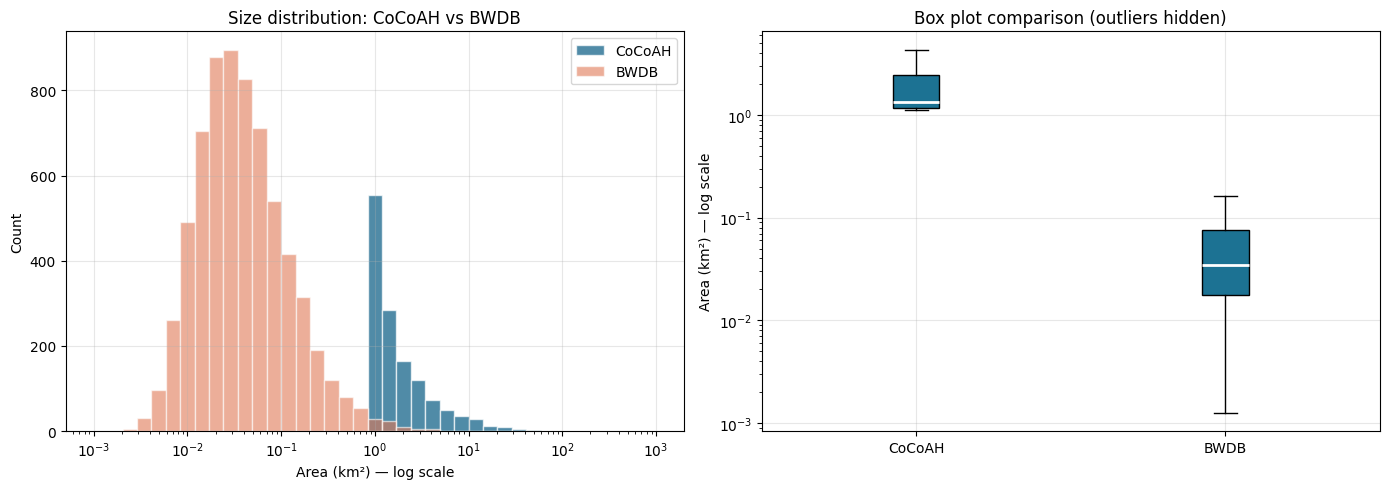

In [5]:
# %%
# =============================================================================
# CELL 4: SIZE DISTRIBUTION HISTOGRAMS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use log scale because both have heavy tails
bins = np.logspace(-3, 3, 40)

axes[0].hist(cocoah_m["area_km2_computed"], bins=bins, alpha=0.7,
             color="#065A82", edgecolor="white", label="CoCoAH")
axes[0].hist(bwdb_m["area_km2_computed"], bins=bins, alpha=0.6,
             color="#E07856", edgecolor="white", label="BWDB")
axes[0].set_xscale("log")
axes[0].set_xlabel("Area (km²) — log scale")
axes[0].set_ylabel("Count")
axes[0].set_title("Size distribution: CoCoAH vs BWDB")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot comparison
axes[1].boxplot([cocoah_m["area_km2_computed"], bwdb_m["area_km2_computed"]],
                labels=["CoCoAH", "BWDB"], showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor="#1C7293", color="black"),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_yscale("log")
axes[1].set_ylabel("Area (km²) — log scale")
axes[1].set_title("Box plot comparison (outliers hidden)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "size_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# %%
# =============================================================================
# CELL 5: SPATIAL OVERLAP ANALYSIS
# =============================================================================
# For each BWDB polygon, find which CoCoAH polygons intersect with it.
# For each CoCoAH polygon, find which BWDB polygons intersect with it.

print("\n=== Computing spatial overlaps (this may take a few minutes) ===")

# Build spatial index for efficient lookups
cocoah_sindex = cocoah_m.sindex

# For each BWDB feature, find overlap with CoCoAH
bwdb_overlap_results = []
for idx, bwdb_row in bwdb_m.iterrows():
    bwdb_geom = bwdb_row.geometry
    bwdb_area = bwdb_geom.area
    
    # Find candidate CoCoAH polygons via spatial index
    candidates_idx = list(cocoah_sindex.intersection(bwdb_geom.bounds))
    
    total_overlap_area = 0
    matching_cocoah_ids = []
    iou_values = []
    
    for c_idx in candidates_idx:
        cocoah_geom = cocoah_m.iloc[c_idx].geometry
        if bwdb_geom.intersects(cocoah_geom):
            intersection = bwdb_geom.intersection(cocoah_geom)
            inter_area = intersection.area
            union_area = bwdb_geom.union(cocoah_geom).area
            iou = inter_area / union_area if union_area > 0 else 0
            
            if inter_area > 0:
                total_overlap_area += inter_area
                matching_cocoah_ids.append(c_idx)
                iou_values.append(iou)
    
    overlap_fraction = total_overlap_area / bwdb_area if bwdb_area > 0 else 0
    max_iou = max(iou_values) if iou_values else 0
    
    bwdb_overlap_results.append({
        "bwdb_idx": idx,
        "bwdb_name": bwdb_row.get("WBNAME", ""),
        "bwdb_type": bwdb_row.get("TYPE", ""),
        "bwdb_area_km2": bwdb_area / 1e6,
        "n_cocoah_overlapping": len(matching_cocoah_ids),
        "overlap_area_km2": total_overlap_area / 1e6,
        "overlap_fraction": overlap_fraction,
        "max_iou": max_iou,
    })
    
    if (idx + 1) % 500 == 0:
        print(f"  Processed {idx + 1}/{len(bwdb_m)} BWDB features")

bwdb_overlap = pd.DataFrame(bwdb_overlap_results)
print(f"\n✓ BWDB overlap analysis complete: {len(bwdb_overlap)} features")


=== Computing spatial overlaps (this may take a few minutes) ===
  Processed 500/6686 BWDB features
  Processed 1000/6686 BWDB features
  Processed 1500/6686 BWDB features
  Processed 2000/6686 BWDB features
  Processed 2500/6686 BWDB features
  Processed 3000/6686 BWDB features
  Processed 3500/6686 BWDB features
  Processed 4000/6686 BWDB features
  Processed 4500/6686 BWDB features
  Processed 5000/6686 BWDB features
  Processed 5500/6686 BWDB features
  Processed 6000/6686 BWDB features
  Processed 6500/6686 BWDB features

✓ BWDB overlap analysis complete: 6686 features


In [7]:
# %%
# =============================================================================
# CELL 6: REVERSE — FOR EACH CoCoAH, FIND OVERLAPPING BWDB
# =============================================================================

print("\n=== Computing reverse overlaps (CoCoAH → BWDB) ===")

bwdb_sindex = bwdb_m.sindex

cocoah_overlap_results = []
for idx, cocoah_row in cocoah_m.iterrows():
    cocoah_geom = cocoah_row.geometry
    cocoah_area = cocoah_geom.area
    
    candidates_idx = list(bwdb_sindex.intersection(cocoah_geom.bounds))
    
    total_overlap_area = 0
    matching_bwdb_ids = []
    matching_bwdb_names = []
    iou_values = []
    
    for b_idx in candidates_idx:
        bwdb_geom = bwdb_m.iloc[b_idx].geometry
        if cocoah_geom.intersects(bwdb_geom):
            intersection = cocoah_geom.intersection(bwdb_geom)
            inter_area = intersection.area
            union_area = cocoah_geom.union(bwdb_geom).area
            iou = inter_area / union_area if union_area > 0 else 0
            
            if inter_area > 0:
                total_overlap_area += inter_area
                matching_bwdb_ids.append(b_idx)
                name = bwdb_m.iloc[b_idx].get("WBNAME", "")
                if name and str(name).strip():
                    matching_bwdb_names.append(str(name))
                iou_values.append(iou)
    
    overlap_fraction = total_overlap_area / cocoah_area if cocoah_area > 0 else 0
    max_iou = max(iou_values) if iou_values else 0
    
    cocoah_overlap_results.append({
        "cocoah_idx": idx,
        "cocoah_area_km2": cocoah_area / 1e6,
        "n_bwdb_overlapping": len(matching_bwdb_ids),
        "overlap_area_km2": total_overlap_area / 1e6,
        "overlap_fraction": overlap_fraction,
        "max_iou": max_iou,
        "matched_names": "; ".join(matching_bwdb_names[:3]),
    })
    
    if (idx + 1) % 200 == 0:
        print(f"  Processed {idx + 1}/{len(cocoah_m)} CoCoAH features")

cocoah_overlap = pd.DataFrame(cocoah_overlap_results)
print(f"\n✓ CoCoAH overlap analysis complete: {len(cocoah_overlap)} features")


=== Computing reverse overlaps (CoCoAH → BWDB) ===
  Processed 200/1345 CoCoAH features
  Processed 400/1345 CoCoAH features
  Processed 600/1345 CoCoAH features
  Processed 800/1345 CoCoAH features
  Processed 1000/1345 CoCoAH features
  Processed 1200/1345 CoCoAH features

✓ CoCoAH overlap analysis complete: 1345 features


In [8]:
# %%
# =============================================================================
# CELL 7: MATCH STATISTICS
# =============================================================================

print("\n" + "=" * 70)
print("MATCH STATISTICS")
print("=" * 70)

# --- BWDB perspective: how many BWDB features were detected by CoCoAH? ---
n_bwdb = len(bwdb_overlap)

bwdb_any = (bwdb_overlap["n_cocoah_overlapping"] > 0).sum()
bwdb_substantial = (bwdb_overlap["overlap_fraction"] >= OVERLAP_THRESHOLD).sum()
bwdb_iou_match = (bwdb_overlap["max_iou"] >= IOU_MATCH_THRESHOLD).sum()
bwdb_no_match = (bwdb_overlap["n_cocoah_overlapping"] == 0).sum()

print(f"\n--- BWDB perspective ({n_bwdb} BWDB features in AOI) ---")
print(f"  Any CoCoAH intersect:         {bwdb_any:>6,} ({100*bwdb_any/n_bwdb:.1f}%)")
print(f"  Substantial overlap (≥50%):   {bwdb_substantial:>6,} ({100*bwdb_substantial/n_bwdb:.1f}%)")
print(f"  IoU match (≥{IOU_MATCH_THRESHOLD:.0%}):              {bwdb_iou_match:>6,} ({100*bwdb_iou_match/n_bwdb:.1f}%)")
print(f"  NO CoCoAH overlap:            {bwdb_no_match:>6,} ({100*bwdb_no_match/n_bwdb:.1f}%)")

# --- CoCoAH perspective: how many CoCoAH features correspond to a real BWDB body? ---
n_cocoah = len(cocoah_overlap)

cocoah_any = (cocoah_overlap["n_bwdb_overlapping"] > 0).sum()
cocoah_substantial = (cocoah_overlap["overlap_fraction"] >= OVERLAP_THRESHOLD).sum()
cocoah_iou_match = (cocoah_overlap["max_iou"] >= IOU_MATCH_THRESHOLD).sum()
cocoah_no_match = (cocoah_overlap["n_bwdb_overlapping"] == 0).sum()

print(f"\n--- CoCoAH perspective ({n_cocoah} CoCoAH features) ---")
print(f"  Any BWDB intersect:           {cocoah_any:>6,} ({100*cocoah_any/n_cocoah:.1f}%)")
print(f"  Substantial overlap (≥50%):   {cocoah_substantial:>6,} ({100*cocoah_substantial/n_cocoah:.1f}%)")
print(f"  IoU match (≥{IOU_MATCH_THRESHOLD:.0%}):              {cocoah_iou_match:>6,} ({100*cocoah_iou_match/n_cocoah:.1f}%)")
print(f"  NO BWDB overlap:              {cocoah_no_match:>6,} ({100*cocoah_no_match/n_cocoah:.1f}%)")

# Confusion-matrix-style summary
print(f"\n--- Interpretation ---")
print(f"  Detection sensitivity (recall on BWDB): {100*bwdb_any/n_bwdb:.1f}%")
print(f"    = % of BWDB features CoCoAH found at all")
print(f"  Precision (CoCoAH→real BWDB):           {100*cocoah_any/n_cocoah:.1f}%")
print(f"    = % of CoCoAH detections that hit any BWDB feature")
print(f"  False positives (CoCoAH not in BWDB):   {cocoah_no_match:,} ({100*cocoah_no_match/n_cocoah:.1f}%)")
print(f"  False negatives (BWDB missed by CoCoAH): {bwdb_no_match:,} ({100*bwdb_no_match/n_bwdb:.1f}%)")



MATCH STATISTICS

--- BWDB perspective (6686 BWDB features in AOI) ---
  Any CoCoAH intersect:            958 (14.3%)
  Substantial overlap (≥50%):      787 (11.8%)
  IoU match (≥30%):                   1 (0.0%)
  NO CoCoAH overlap:             5,728 (85.7%)

--- CoCoAH perspective (1345 CoCoAH features) ---
  Any BWDB intersect:              443 (32.9%)
  Substantial overlap (≥50%):        2 (0.1%)
  IoU match (≥30%):                   1 (0.1%)
  NO BWDB overlap:                 902 (67.1%)

--- Interpretation ---
  Detection sensitivity (recall on BWDB): 14.3%
    = % of BWDB features CoCoAH found at all
  Precision (CoCoAH→real BWDB):           32.9%
    = % of CoCoAH detections that hit any BWDB feature
  False positives (CoCoAH not in BWDB):   902 (67.1%)
  False negatives (BWDB missed by CoCoAH): 5,728 (85.7%)


In [9]:
# %%
# =============================================================================
# CELL 8: SIZE-STRATIFIED ANALYSIS
# =============================================================================
# Match rate likely varies by BWDB feature size — large haors easier to detect

print("\n=== Match rate by BWDB feature size ===")

size_bins = [0, 0.05, 0.1, 0.5, 1.0, 5.0, 100]
size_labels = ["<0.05", "0.05-0.1", "0.1-0.5", "0.5-1.0", "1.0-5.0", ">5.0"]

bwdb_overlap["size_bin"] = pd.cut(bwdb_overlap["bwdb_area_km2"],
                                   bins=size_bins, labels=size_labels)

size_strat = bwdb_overlap.groupby("size_bin").agg(
    n_features=("bwdb_idx", "count"),
    any_match=("n_cocoah_overlapping", lambda x: (x > 0).sum()),
    iou_match=("max_iou", lambda x: (x >= IOU_MATCH_THRESHOLD).sum()),
    mean_overlap_fraction=("overlap_fraction", "mean"),
    mean_max_iou=("max_iou", "mean"),
)
size_strat["any_match_pct"] = 100 * size_strat["any_match"] / size_strat["n_features"]
size_strat["iou_match_pct"] = 100 * size_strat["iou_match"] / size_strat["n_features"]

print(size_strat.round(2))



=== Match rate by BWDB feature size ===
          n_features  any_match  iou_match  mean_overlap_fraction  \
size_bin                                                            
<0.05           4218        525          0                   0.11   
0.05-0.1        1221        182          0                   0.12   
0.1-0.5         1093        215          0                   0.16   
0.5-1.0          102         29          1                   0.18   
1.0-5.0           51          7          0                   0.07   
>5.0               1          0          0                   0.00   

          mean_max_iou  any_match_pct  iou_match_pct  
size_bin                                              
<0.05             0.00          12.45           0.00  
0.05-0.1          0.00          14.91           0.00  
0.1-0.5           0.01          19.67           0.00  
0.5-1.0           0.04          28.43           0.98  
1.0-5.0           0.02          13.73           0.00  
>5.0              0.0

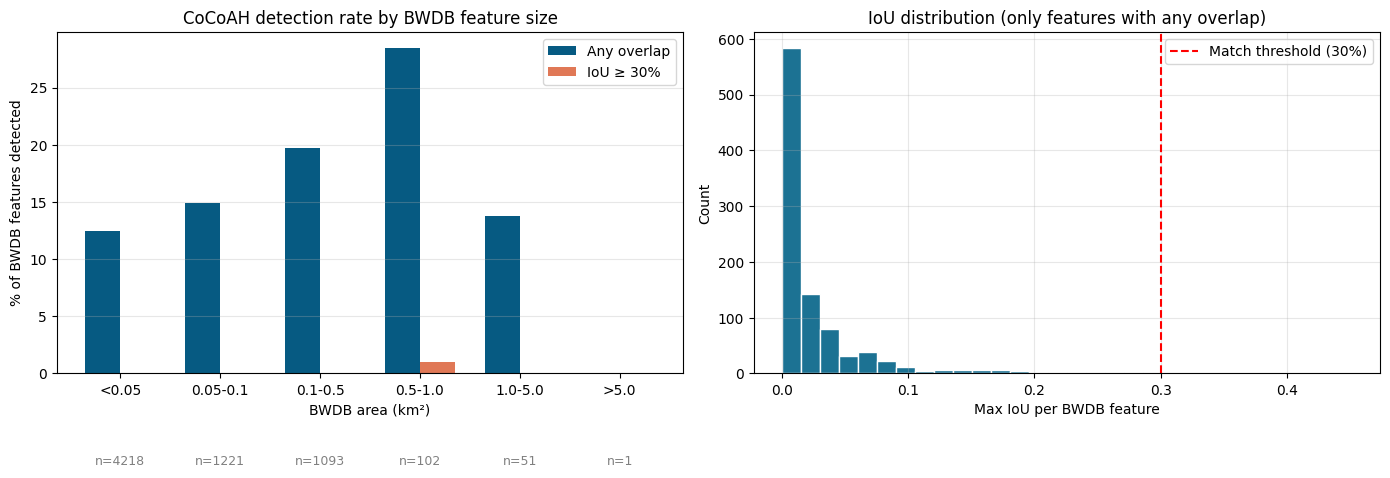

In [10]:
# %%
# =============================================================================
# CELL 9: PLOT — MATCH RATE BY SIZE
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(size_labels))
width = 0.35

axes[0].bar(x - width/2, size_strat["any_match_pct"], width,
            color="#065A82", label="Any overlap")
axes[0].bar(x + width/2, size_strat["iou_match_pct"], width,
            color="#E07856", label=f"IoU ≥ {IOU_MATCH_THRESHOLD:.0%}")
axes[0].set_xticks(x)
axes[0].set_xticklabels(size_labels)
axes[0].set_xlabel("BWDB area (km²)")
axes[0].set_ylabel("% of BWDB features detected")
axes[0].set_title("CoCoAH detection rate by BWDB feature size")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Add count labels
for i, n in enumerate(size_strat["n_features"]):
    axes[0].text(i, -8, f"n={int(n)}", ha="center", fontsize=9, color="gray")

# IoU distribution
axes[1].hist(bwdb_overlap[bwdb_overlap["max_iou"] > 0]["max_iou"],
             bins=30, color="#1C7293", edgecolor="white")
axes[1].axvline(IOU_MATCH_THRESHOLD, color="red", linestyle="--",
                label=f"Match threshold ({IOU_MATCH_THRESHOLD:.0%})")
axes[1].set_xlabel("Max IoU per BWDB feature")
axes[1].set_ylabel("Count")
axes[1].set_title("IoU distribution (only features with any overlap)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "match_rate_by_size.png"), dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# %%
# =============================================================================
# CELL 10: ANALYSIS BY BWDB TYPE/NAME
# =============================================================================
# How does match rate vary across "Haor", "Beel", other named features?

print("\n=== Match rate by named feature category ===")

def classify_name(name):
    if not name or pd.isna(name):
        return "Unnamed"
    n = str(name).lower()
    if "haor" in n:
        return "Named Haor"
    elif "beel" in n:
        return "Named Beel"
    elif "khal" in n or "river" in n or "nadi" in n:
        return "River/Khal"
    elif "lake" in n:
        return "Lake"
    else:
        return "Other named"

bwdb_overlap["category"] = bwdb_overlap["bwdb_name"].apply(classify_name)

cat_strat = bwdb_overlap.groupby("category").agg(
    n=("bwdb_idx", "count"),
    any_match=("n_cocoah_overlapping", lambda x: (x > 0).sum()),
    iou_match=("max_iou", lambda x: (x >= IOU_MATCH_THRESHOLD).sum()),
    mean_iou=("max_iou", "mean"),
    mean_overlap_pct=("overlap_fraction", lambda x: 100 * x.mean()),
    mean_size_km2=("bwdb_area_km2", "mean"),
)
cat_strat["any_match_pct"] = 100 * cat_strat["any_match"] / cat_strat["n"]
cat_strat["iou_match_pct"] = 100 * cat_strat["iou_match"] / cat_strat["n"]
cat_strat = cat_strat.sort_values("n", ascending=False)

print(cat_strat.round(2))


=== Match rate by named feature category ===
                n  any_match  iou_match  mean_iou  mean_overlap_pct  \
category                                                              
Unnamed      5501        715          0      0.00             10.74   
Named Beel   1131        234          1      0.01             16.52   
Named Haor     44          7          0      0.00              7.68   
Other named     6          1          0      0.03             14.97   
Lake            3          1          0      0.02             29.45   
River/Khal      1          0          0      0.00              0.00   

             mean_size_km2  any_match_pct  iou_match_pct  
category                                                  
Unnamed               0.06          13.00           0.00  
Named Beel            0.19          20.69           0.09  
Named Haor            0.18          15.91           0.00  
Other named           0.22          16.67           0.00  
Lake                  0.32     

In [12]:
# %%
# =============================================================================
# CELL 11: NAMED HAORS SPECIFICALLY — HEAD-TO-HEAD
# =============================================================================
# This is the most important table: how well did CoCoAH detect the 49 named
# "Haor" features in BWDB?

print("\n=== Named Haors — detailed match table ===")

named_haors = bwdb_overlap[bwdb_overlap["category"] == "Named Haor"].copy()
named_haors = named_haors.sort_values("bwdb_area_km2", ascending=False)

display_cols = ["bwdb_name", "bwdb_area_km2", "n_cocoah_overlapping",
                "overlap_fraction", "max_iou"]
print(f"\nAll {len(named_haors)} named haors:")
print(named_haors[display_cols].to_string(index=False,
    formatters={
        "bwdb_area_km2": "{:.2f}".format,
        "overlap_fraction": "{:.2%}".format,
        "max_iou": "{:.2f}".format,
    }))

# Save to CSV for thesis
named_haors.to_csv(os.path.join(OUT_DIR, "named_haor_validation.csv"), index=False)
print(f"\n✓ Saved: {os.path.join(OUT_DIR, 'named_haor_validation.csv')}")



=== Named Haors — detailed match table ===

All 44 named haors:
     bwdb_name bwdb_area_km2  n_cocoah_overlapping overlap_fraction max_iou
    Pasna Haor          1.29                     0            0.00%    0.00
   Banuar Haor          1.13                     0            0.00%    0.00
     Sona Haor          1.00                     0            0.00%    0.00
     Bara haor          0.81                     0            0.00%    0.00
     Lali Haor          0.56                     0            0.00%    0.00
   Matian Haor          0.46                     0            0.00%    0.00
 Balahaor beel          0.42                     0            0.00%    0.00
     Baoa Haor          0.32                     0            0.00%    0.00
Pokohaoir Haor          0.28                     0            0.00%    0.00
    Lobha Haor          0.25                     0            0.00%    0.00
     Baoa Haor          0.18                     0            0.00%    0.00
   Baldia Haor         

In [13]:
# %%
# =============================================================================
# CELL 12: ONE-TO-MANY ANALYSIS
# =============================================================================
# Often a single BWDB haor matches multiple CoCoAH polygons (CoCoAH over-segments)
# Or a single CoCoAH polygon matches multiple BWDB features (CoCoAH merges them)

print("\n=== Over/Under-segmentation analysis ===")

print(f"\nBWDB features matched by N CoCoAH polygons:")
bwdb_multi = bwdb_overlap["n_cocoah_overlapping"].value_counts().sort_index().head(10)
for n, count in bwdb_multi.items():
    print(f"  {n} CoCoAH polygons: {count} BWDB features ({100*count/len(bwdb_overlap):.1f}%)")

print(f"\nCoCoAH features matched by N BWDB polygons:")
cocoah_multi = cocoah_overlap["n_bwdb_overlapping"].value_counts().sort_index().head(10)
for n, count in cocoah_multi.items():
    print(f"  {n} BWDB polygons: {count} CoCoAH features ({100*count/len(cocoah_overlap):.1f}%)")

over_seg = (bwdb_overlap["n_cocoah_overlapping"] > 1).sum()
under_seg = (cocoah_overlap["n_bwdb_overlapping"] > 1).sum()
one_to_one = ((bwdb_overlap["n_cocoah_overlapping"] == 1)).sum()

print(f"\n--- Segmentation summary ---")
print(f"  Over-segmentation (1 BWDB → multiple CoCoAH):  {over_seg:,} BWDB features")
print(f"  Under-segmentation (1 CoCoAH → multiple BWDB): {under_seg:,} CoCoAH features")
print(f"  1-to-1 matches:                                  {one_to_one:,} BWDB features")



=== Over/Under-segmentation analysis ===

BWDB features matched by N CoCoAH polygons:
  0 CoCoAH polygons: 5728 BWDB features (85.7%)
  1 CoCoAH polygons: 945 BWDB features (14.1%)
  2 CoCoAH polygons: 12 BWDB features (0.2%)
  3 CoCoAH polygons: 1 BWDB features (0.0%)

CoCoAH features matched by N BWDB polygons:
  0 BWDB polygons: 902 CoCoAH features (67.1%)
  1 BWDB polygons: 231 CoCoAH features (17.2%)
  2 BWDB polygons: 111 CoCoAH features (8.3%)
  3 BWDB polygons: 35 CoCoAH features (2.6%)
  4 BWDB polygons: 24 CoCoAH features (1.8%)
  5 BWDB polygons: 17 CoCoAH features (1.3%)
  6 BWDB polygons: 6 CoCoAH features (0.4%)
  7 BWDB polygons: 5 CoCoAH features (0.4%)
  8 BWDB polygons: 4 CoCoAH features (0.3%)
  9 BWDB polygons: 1 CoCoAH features (0.1%)

--- Segmentation summary ---
  Over-segmentation (1 BWDB → multiple CoCoAH):  13 BWDB features
  Under-segmentation (1 CoCoAH → multiple BWDB): 212 CoCoAH features
  1-to-1 matches:                                  945 BWDB features


=== Generating validation map ===


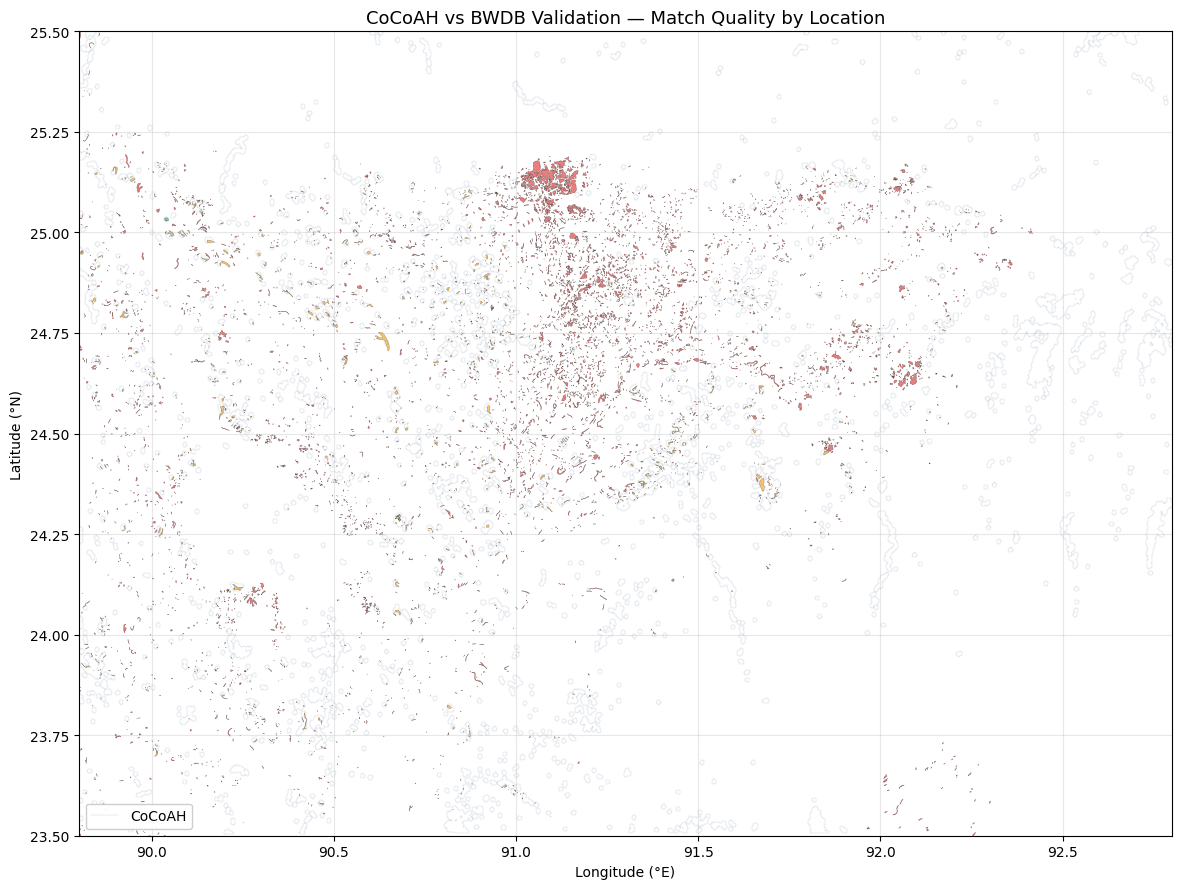

In [14]:
# %%
# =============================================================================
# CELL 13: SPATIAL MAP — WHERE DO MATCHES/MISMATCHES OCCUR?
# =============================================================================

print("\n=== Generating validation map ===")

# Reproject back to geographic for plotting with familiar coordinates
cocoah_geo = cocoah_m.to_crs("EPSG:4326")
bwdb_geo = bwdb_m.to_crs("EPSG:4326")

# Add validation results back to the geo dataframes
bwdb_geo = bwdb_geo.reset_index(drop=True)
bwdb_geo["max_iou"] = bwdb_overlap["max_iou"].values
bwdb_geo["overlap_fraction"] = bwdb_overlap["overlap_fraction"].values
bwdb_geo["match_quality"] = pd.cut(
    bwdb_geo["max_iou"],
    bins=[-0.01, 0.001, IOU_MATCH_THRESHOLD, 1.0],
    labels=["No match", "Partial", "Good match"]
)

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

# CoCoAH in light blue (background)
cocoah_geo.boundary.plot(ax=ax, color="#94A3B8", linewidth=0.3, alpha=0.5,
                         label="CoCoAH")

# BWDB colored by match quality
colors_map = {"No match": "#DC2626", "Partial": "#F59E0B", "Good match": "#10B981"}
for quality, color in colors_map.items():
    subset = bwdb_geo[bwdb_geo["match_quality"] == quality]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, alpha=0.6, edgecolor="black",
                   linewidth=0.2, label=f"BWDB {quality} (n={len(subset)})")

ax.set_xlim(HAOR_BBOX[0], HAOR_BBOX[2])
ax.set_ylim(HAOR_BBOX[1], HAOR_BBOX[3])
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("CoCoAH vs BWDB Validation — Match Quality by Location", fontsize=13)
ax.legend(loc="lower left", framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "validation_map.png"), dpi=200, bbox_inches="tight")
plt.show()



=== Area agreement for matched pairs ===


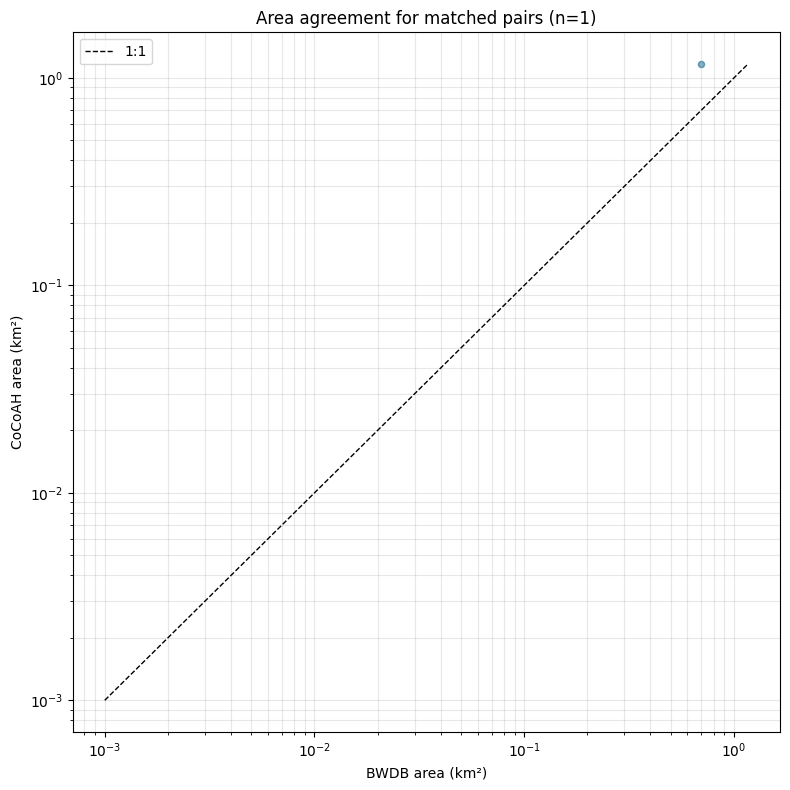


Log10(CoCoAH/BWDB) statistics:
  Mean:   0.224  (positive = CoCoAH larger)
  Median: 0.224
  Std:    nan
  Log-log correlation: nan


In [15]:
# %%
# =============================================================================
# CELL 14: AREA AGREEMENT SCATTER PLOT
# =============================================================================
# For matched pairs, how well does CoCoAH area match BWDB area?

print("\n=== Area agreement for matched pairs ===")

# Filter to BWDB features with at least one CoCoAH match
matched_pairs = bwdb_overlap[bwdb_overlap["max_iou"] >= IOU_MATCH_THRESHOLD].copy()

# For each, get the best-matching CoCoAH area
matched_pairs["best_cocoah_area_km2"] = np.nan

for idx, row in matched_pairs.iterrows():
    bwdb_idx = int(row["bwdb_idx"])
    bwdb_geom = bwdb_m.iloc[bwdb_idx].geometry
    best_iou = 0
    best_area = 0
    candidates = list(cocoah_sindex.intersection(bwdb_geom.bounds))
    for c_idx in candidates:
        c_geom = cocoah_m.iloc[c_idx].geometry
        if bwdb_geom.intersects(c_geom):
            inter = bwdb_geom.intersection(c_geom).area
            union = bwdb_geom.union(c_geom).area
            iou = inter / union if union > 0 else 0
            if iou > best_iou:
                best_iou = iou
                best_area = c_geom.area / 1e6
    matched_pairs.at[idx, "best_cocoah_area_km2"] = best_area

valid = matched_pairs[matched_pairs["best_cocoah_area_km2"] > 0].copy()

if len(valid) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.scatter(valid["bwdb_area_km2"], valid["best_cocoah_area_km2"],
              alpha=0.5, color="#065A82", s=20)
    
    # 1:1 line
    max_val = max(valid["bwdb_area_km2"].max(), valid["best_cocoah_area_km2"].max())
    ax.plot([0.001, max_val], [0.001, max_val], "k--", linewidth=1, label="1:1")
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("BWDB area (km²)")
    ax.set_ylabel("CoCoAH area (km²)")
    ax.set_title(f"Area agreement for matched pairs (n={len(valid)})")
    ax.legend()
    ax.grid(True, alpha=0.3, which="both")
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "area_agreement.png"), dpi=150, bbox_inches="tight")
    plt.show()
    
    # Statistics
    log_ratio = np.log10(valid["best_cocoah_area_km2"] / valid["bwdb_area_km2"])
    print(f"\nLog10(CoCoAH/BWDB) statistics:")
    print(f"  Mean:   {log_ratio.mean():.3f}  (positive = CoCoAH larger)")
    print(f"  Median: {log_ratio.median():.3f}")
    print(f"  Std:    {log_ratio.std():.3f}")
    
    correlation = np.corrcoef(np.log10(valid["bwdb_area_km2"]),
                              np.log10(valid["best_cocoah_area_km2"]))[0, 1]
    print(f"  Log-log correlation: {correlation:.3f}")
